Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
df = pd.read_parquet('/Users/kaungkhantkyaw/Documents/GitHub/Analyse-US-Domestic-flights/Data/Cleaned/DB1B_Market_2025_1_cleaned.parquet')
print(df.columns)

Index(['ItinID', 'MktID', 'MktCoupons', 'Year', 'Quarter',
       'OriginCityMarketID', 'Origin', 'OriginState', 'DestCityMarketID',
       'Dest', 'DestState', 'TkCarrierChange', 'OpCarrierChange', 'RPCarrier',
       'TkCarrier', 'OpCarrier', 'Passengers', 'MktFare', 'MktDistance',
       'MktDistanceGroup', 'NonStopMiles', 'MktGeoType', 'fare_group'],
      dtype='str')
(7290528, 23)


Part 1: Additional exploration of MktFare ontop of whats done in notebook 1

In [12]:
low_fare = df['MktFare'].quantile(0.01)
high_fare = df['MktFare'].quantile(0.99)

df_eda = df[(df['MktFare'] >= low_fare) & (df['MktFare'] <= high_fare)].copy()
df_eda['Route'] = df_eda['Origin'] + '-' + df_eda['Dest']
print(df_eda.shape)

(7189747, 24)


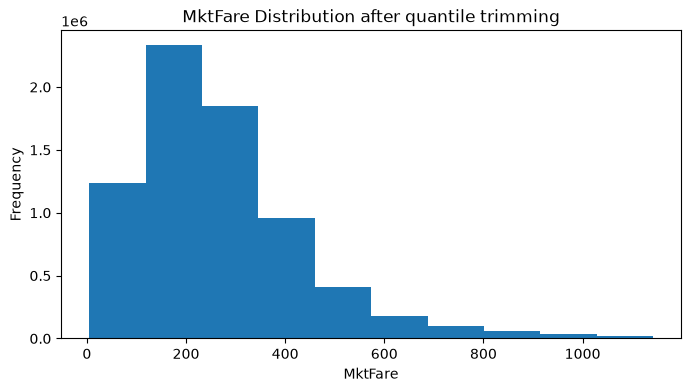

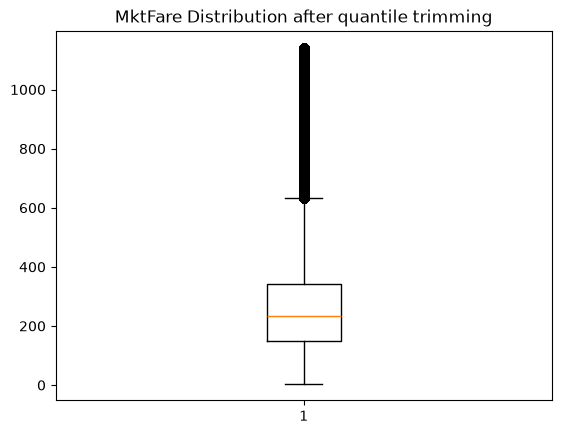

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(df_eda['MktFare'])
plt.title('MktFare Distribution after quantile trimming')
plt.xlabel('MktFare')
plt.ylabel('Frequency')
plt.show()

plt.boxplot(df_eda['MktFare'])
plt.title('MktFare Distribution after quantile trimming')
plt.show()

Fares are right skewed as observable in the histogram. Quantile trimming was also carried to remove extreme outliers on both ends

Part 2: Fare by Distance
How does fare vary with distance/distance group

,MktDistanceGroup,count,mean,median
0,1,899228,205.09,184.50
1,2,2220201,234.94,210.00
2,3,1778246,261.34,231.50
3,4,989613,300.19,267.00
4,5,756823,318.50,279.00
5,6,349626,323.17,282.00
6,7,62966,347.16,316.00
7,8,40363,389.84,355.50
8,9,39937,422.68,394.21
9,10,35388,432.72,411.00


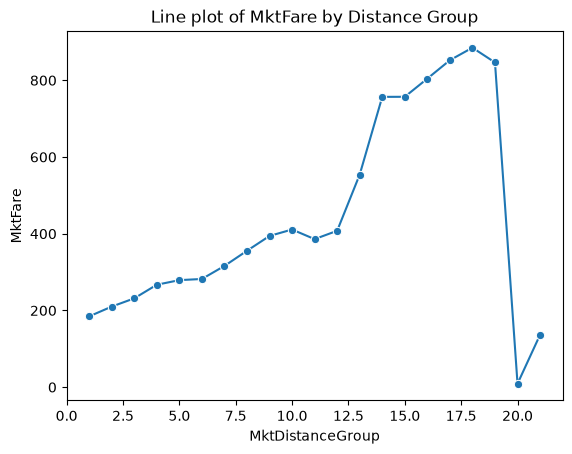

In [33]:
distance_fare_table = df_eda.groupby('MktDistanceGroup')['MktFare'].agg(count = 'count', mean = 'mean', median = 'median').reset_index()
display(distance_fare_table)
#After trimming, this is the fare distribution by distance group table

sns.lineplot(x = 'MktDistanceGroup', y = 'MktFare', data = df_eda, estimator = 'median', marker='o', errorbar=None)
plt.title('Line plot of MktFare by Distance Group')
plt.show()

With reference to the line plot above, Fare increases at a rather linear state until the middle group, then it sharply increases until around the 18th group. Sample sizes from 19th onwards are very minimal, with 20,21 and 23 being 3 and under. 

Part 3: Route level Analysis

In [ ]:
route_fare_analytics = df_eda.groupby('Route').agg(records = ('MktFare', 'count'), avg_fare = ('MktFare', 'mean'), median_fare= ('MktFare', 'median'), total_passengers = ('Passengers', 'sum'), min_fare = ('MktFare', 'min'), max_fare = ('MktFare', 'max')).reset_index()
display(route_fare_analytics.sample(30))
percentage_passengers = route_fare_analytics.loc[route_fare_analytics['total_passengers'] >= 100, 'total_passengers'].sum() / route_fare_analytics['total_passengers'].sum()
print(f'Routes kept: {(route_fare_analytics['total_passengers'] >= 100).mean():.1%}')
print(f'Passengers kept: {percentage_passengers:.1%}')

,Route,records,avg_fare,median_fare,total_passengers,min_fare,max_fare
19028,ECP-SUN,2,589.00,589.00,2.00,479.00,699.00
10431,CAE-MOT,5,417.38,356.00,5.00,174.00,644.00
2531,ANC-BIS,19,488.65,477.00,19.00,5.50,1099.00
45315,ONT-PWM,15,370.70,335.00,15.00,5.00,624.19
58398,SJU-LWS,1,5.50,5.50,1.00,5.50,5.50
16278,DCA-RIW,2,473.00,473.00,2.00,331.50,614.50
25739,GRR-GSO,88,239.47,231.53,94.00,5.00,537.93
18550,EAR-DCA,3,634.68,471.50,3.00,302.54,1130.00
48702,PIT-MCW,3,141.78,159.50,3.00,82.31,183.54
49299,PRC-HDN,1,252.00,252.00,1.00,252.00,252.00


Routes kept: 17.7%
Passengers kept: 94.0%


In [126]:
display(route_fare_analytics.sort_values(by = 'avg_fare', ascending = True).head(10))
display(route_fare_analytics.sort_values(by = 'avg_fare', ascending = False).head(10))

,Route,records,avg_fare,median_fare,total_passengers,min_fare,max_fare
8190,BQK-PIH,1,5.00,5.00,1.00,5.00,5.00
20874,EYW-FAI,1,5.00,5.00,1.00,5.00,5.00
2113,ALO-JAN,1,5.00,5.00,1.00,5.00,5.00
44403,OGG-SHR,1,5.00,5.00,1.00,5.00,5.00
1132,ACV-GJT,1,5.00,5.00,1.00,5.00,5.00
2125,ALO-MSY,1,5.00,5.00,1.00,5.00,5.00
44277,OGG-GRK,1,5.00,5.00,1.00,5.00,5.00
33316,LAR-JAC,1,5.00,5.00,1.00,5.00,5.00
28855,HSV-WRG,1,5.00,5.00,1.00,5.00,5.00
25287,GRB-RDM,1,5.00,5.00,1.00,5.00,5.00


,Route,records,avg_fare,median_fare,total_passengers,min_fare,max_fare
55640,SCC-SLC,1,1142.00,1142.00,1.00,1142.00,1142.00
36805,LWS-GTR,1,1142.00,1142.00,1.00,1142.00,1142.00
64957,XWA-AVL,1,1137.50,1137.50,1.00,1137.50,1137.50
56431,SEA-SPN,1,1134.31,1134.31,1.00,1134.31,1134.31
31129,ITH-IDA,1,1130.00,1130.00,1.00,1130.00,1130.00
30739,IND-LAR,1,1125.33,1125.33,1.00,1125.33,1125.33
58445,SJU-PIR,1,1123.44,1123.44,1.00,1123.44,1123.44
35911,LIH-ROW,1,1122.68,1122.68,1.00,1122.68,1122.68
6073,BIL-ABY,1,1120.75,1120.75,1.00,1120.75,1120.75
15545,DAB-STX,1,1120.69,1120.69,1.00,1120.69,1120.69


(65418, 7)
(11553, 7)


,index,Route,records,avg_fare,median_fare,total_passengers,min_fare,max_fare
0,34051,LAX-JFK,5788,408.66,328.08,24541.00,5.00,1141.50
1,32256,JFK-LAX,5684,402.91,323.90,24082.00,5.00,1141.50
2,37936,MCO-EWR,3858,226.41,186.00,22926.00,5.00,1108.00
3,20653,EWR-MCO,3723,222.61,184.00,22742.00,5.00,1108.00
4,40278,MIA-LGA,5839,266.09,203.00,22183.00,5.00,1142.00
5,35470,LGA-MIA,5847,259.26,198.50,21989.00,5.00,1141.00
6,45585,ORD-LGA,8061,215.60,189.00,21144.00,5.00,1094.00
7,34184,LAX-SFO,5669,147.77,127.50,21048.00,5.00,1042.00
8,35495,LGA-ORD,8142,217.52,189.50,21009.00,5.00,1091.00
9,56722,SFO-LAX,5762,149.24,128.00,20810.00,5.00,1108.00


,index,Route,records,avg_fare,median_fare,total_passengers,min_fare,max_fare
0,63792,TYS-ALB,96,239.72,200.72,100.00,5.26,949.00
1,64583,VPS-SMF,86,287.06,261.00,100.00,5.00,789.00
2,35823,LIH-IAH,96,431.28,400.78,100.00,5.32,972.84
3,56647,SFO-EYW,99,353.28,286.15,100.00,5.00,1085.68
4,56305,SEA-LEX,98,331.86,317.36,100.00,5.00,688.00
5,35643,LGB-ITO,84,275.11,278.36,100.00,5.00,888.57
6,45621,ORD-MSN,96,212.00,188.75,100.00,5.00,1068.00
7,55682,SCE-DEN,92,323.85,288.75,100.00,5.00,836.50
8,21512,FAT-ABQ,93,230.41,229.00,100.00,5.00,609.00
9,55097,SBN-DCA,89,215.74,199.00,100.00,5.00,554.00


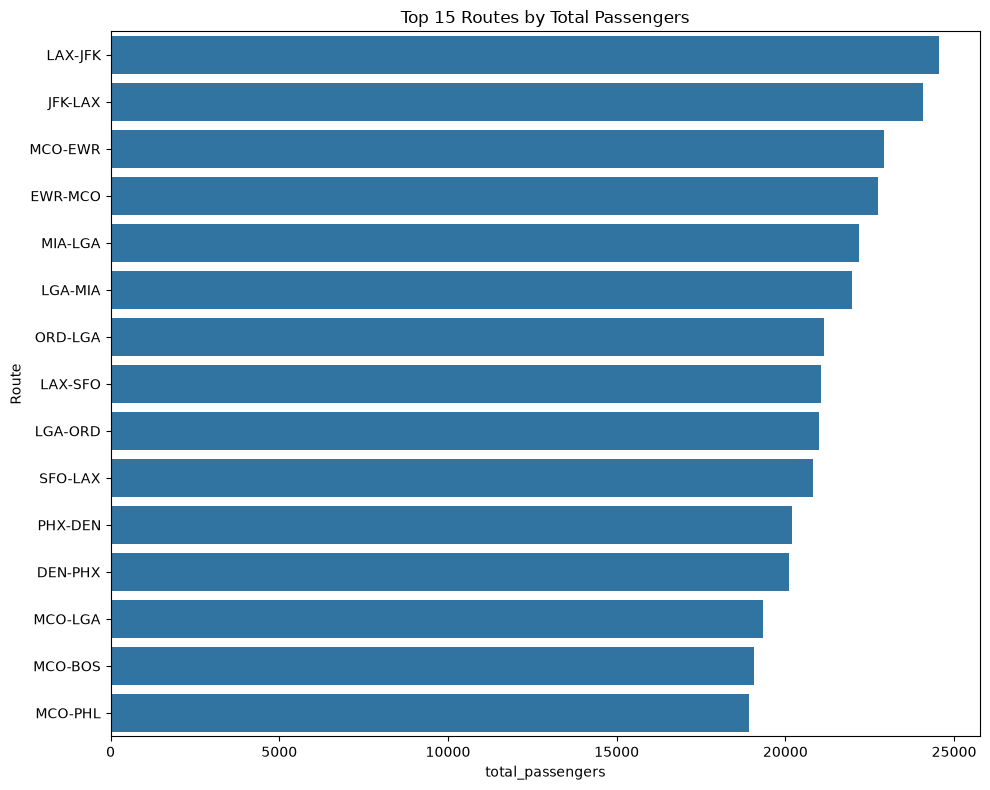

In [132]:
min_passenger_filter = 100
route_fare_analytics_filtered = route_fare_analytics[route_fare_analytics['total_passengers'] >= min_passenger_filter]
print(route_fare_analytics.shape)
print(route_fare_analytics_filtered.shape)
top_route_fare_analytics_filtered = route_fare_analytics_filtered.sort_values(by = 'total_passengers', ascending = False).head(15).reset_index()
display(top_route_fare_analytics_filtered)
bottom_route_fare_analytics_filtered = route_fare_analytics_filtered.sort_values(by = 'total_passengers', ascending = True).head(15).reset_index()
display(bottom_route_fare_analytics_filtered)

plt.figure(figsize=(10, 8))
sns.barplot(y = 'Route', x= 'total_passengers', data=top_route_fare_analytics_filtered)
plt.title('Top 15 Routes by Total Passengers')
plt.tight_layout()
plt.show()

From this barplot, the top 15 contains qutite a few repeats, be it the opposite direction of travel or major hubs like LAX and MCO being part of different routes. Passengers are fairly competitive with a steady decline from 1st to 15th

,index,Route,records,avg_fare,median_fare,total_passengers,min_fare,max_fare
0,27659,HNL-GUM,63,674.38,821.50,141.00,5.00,1138.00
1,26944,GUM-HNL,67,699.54,819.73,144.00,7.00,1138.00
2,27616,HNL-DTW,626,567.88,604.50,842.00,5.00,1140.00
3,18259,DTW-HNL,592,567.50,598.77,815.00,5.00,1140.00
4,27764,HNL-PPG,109,587.13,595.00,290.00,6.00,1037.00
5,49209,PPG-HNL,111,577.82,586.00,297.00,7.50,1037.00
6,27667,HNL-HSV,98,580.81,580.75,103.00,5.32,1102.87
7,27669,HNL-IAD,735,532.63,574.00,1011.00,5.00,1137.00
8,29228,IAD-HNL,676,533.08,571.75,942.00,5.00,1142.00
9,29530,IAH-FAI,109,512.29,509.00,130.00,5.36,1062.00


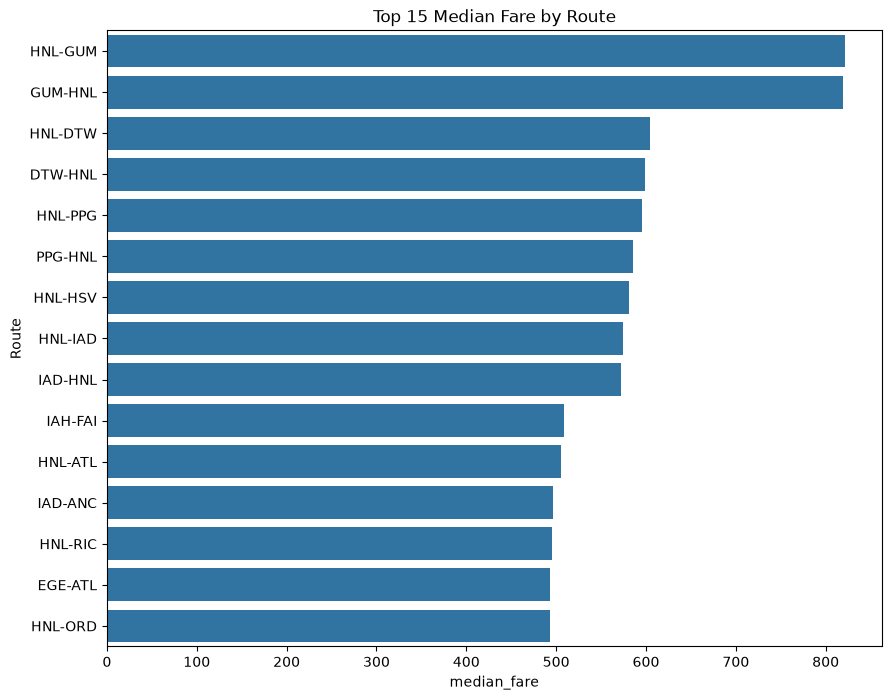

In [80]:
median_route_fare_analytics_filtered = route_fare_analytics_filtered.sort_values(by = 'median_fare', ascending=False).head(15).reset_index()
display(median_route_fare_analytics_filtered)

plt.figure(figsize=(10, 8))
sns.barplot(data=median_route_fare_analytics_filtered, y = 'Route', x = 'median_fare')
plt.title('Top 15 Median Fare by Route')
plt.tight_layout
plt.show()

The top 15 median fare consist mostly routes that are non-mainland US, with a few exceptions like EGE-ATL. HNL is the most repeated airport in this. Most median fares are not far off each other, with the clear exception of HNL-GUM and GUM-HNL

In [133]:
display(top_route_fare_analytics_filtered['median_fare'].median())
display(bottom_route_fare_analytics_filtered['median_fare'].median())

np.float64(186.0)

np.float64(261.0)

In [130]:
average_route_fare_analytics_filtered = route_fare_analytics_filtered.sort_values(by = 'avg_fare', ascending = False).head(1).reset_index()
display(route_fare_analytics_filtered.sort_values(by = 'avg_fare', ascending = True).head(1).reset_index())
display(average_route_fare_analytics_filtered)

,index,Route,records,avg_fare,median_fare,total_passengers,min_fare,max_fare
0,47057,PGD-SAV,52,27.06,24.25,121.00,5.00,74.00


,index,Route,records,avg_fare,median_fare,total_passengers,min_fare,max_fare
0,26944,GUM-HNL,67,699.54,819.73,144.00,7.00,1138.00


Part 4: Carrier Analysis

Which carriers have higher median fares?

In [95]:
df_eda.groupby('MktDistanceGroup').size()

MktDistanceGroup
1      899228
2     2220201
3     1778246
4      989613
5      756823
6      349626
7       62966
8       40363
9       39937
10      35388
11      15684
12        871
13        331
14        188
15         50
16         67
17         58
18         96
19          8
20          1
21          2
dtype: int64

In [93]:
carrier_analysis = df_eda.groupby('TkCarrier')['MktFare'].agg(count = 'count', mean = 'mean', median = 'median')
display(carrier_analysis.sort_values(by = 'count', ascending = False).reset_index())
display(carrier_analysis.sort_values(by = 'count', ascending = True).reset_index())

,TkCarrier,count,mean,median
0,AA,1645970,290.56,258.00
1,WN,1468019,228.43,213.00
2,DL,1411970,314.56,285.00
3,UA,1254603,300.72,265.00
4,AS,362120,267.57,232.50
5,NK,230896,115.01,96.69
6,F9,222557,108.24,93.00
7,G4,170105,95.00,78.50
8,B6,165012,250.33,207.32
9,99,107510,279.05,246.41


,TkCarrier,count,mean,median
0,SQ,1,366.00,366.00
1,ET,1,262.50,262.50
2,RJ,1,207.00,207.00
3,CX,1,109.00,109.00
4,AM,1,347.00,347.00
5,AY,1,301.00,301.00
6,TP,1,251.50,251.50
7,AC,1,983.00,983.00
8,FJ,2,377.75,377.75
9,BA,2,479.89,479.89


The top 4 Carriers dominate most of the market, with a total count of 5,780,562 records

In [131]:
display(carrier_analysis.sort_values(by = 'mean', ascending = False).head(1))
display(carrier_analysis.sort_values(by = 'mean', ascending = True).head(1))

,count,mean,median
TkCarrier,,,
AC,1,983.00,983.00


,count,mean,median
TkCarrier,,,
9K,19,89.13,114.00


In [87]:
df_eda.groupby('MktDistanceGroup')['MktDistance'].agg(median = 'median').reset_index()

,MktDistanceGroup,median
0,1,370.00
1,2,765.00
2,3,1185.00
3,4,1723.00
4,5,2252.00
5,6,2633.00
6,7,3208.00
7,8,3784.00
8,9,4217.00
9,10,4791.00


In [98]:
display(df_eda[df_eda['MktDistanceGroup'] == 1].groupby('TkCarrier')['MktFare'].agg(count = 'count', median_carrier_fare = 'median').sort_values(by = 'median_carrier_fare', ascending = False).reset_index())
display(df_eda[df_eda['MktDistanceGroup'] == 3].groupby('TkCarrier')['MktFare'].agg(count = 'count', median_carrier_fare = 'median').sort_values(by = 'median_carrier_fare', ascending = False).reset_index())
display(df_eda[df_eda['MktDistanceGroup'] == 5].groupby('TkCarrier')['MktFare'].agg(count = 'count', median_carrier_fare = 'median').sort_values(by = 'median_carrier_fare', ascending = False).reset_index())
display(df_eda[df_eda['MktDistanceGroup'] == 7].groupby('TkCarrier')['MktFare'].agg(count = 'count', median_carrier_fare = 'median').sort_values(by = 'median_carrier_fare', ascending = False).reset_index())
display(df_eda[df_eda['MktDistanceGroup'] == 10].groupby('TkCarrier')['MktFare'].agg(count = 'count', median_carrier_fare = 'median').sort_values(by = 'median_carrier_fare', ascending = False).reset_index())

,TkCarrier,count,median_carrier_fare
0,QF,1,1074.00
1,FJ,2,377.75
2,AY,1,301.00
3,BA,1,281.00
4,DL,167904,228.50
5,AA,191806,223.00
6,UA,156385,200.00
7,99,7418,180.23
8,WN,231257,168.00
9,VC,2,157.79


,TkCarrier,count,median_carrier_fare
0,DL,312607,286.50
1,UA,286974,271.00
2,PR,2,271.00
3,KG,2,267.46
4,AA,423650,262.70
5,AS,43196,233.00
6,99,29493,232.25
7,HA,564,225.00
8,WN,379614,222.00
9,RJ,1,207.00


,TkCarrier,count,median_carrier_fare
0,PR,9,329.00
1,DL,163022,327.50
2,UA,152321,310.00
3,99,12823,296.16
4,AA,185645,290.00
5,AS,51921,275.00
6,SY,522,273.50
7,B6,17734,262.00
8,HA,12948,248.00
9,WN,116137,245.16


,TkCarrier,count,median_carrier_fare
0,UA,12184,380.50
1,DL,10993,334.95
2,AS,11958,329.50
3,HA,1954,316.50
4,99,2706,313.50
5,AA,10163,307.00
6,SY,2,305.00
7,WN,9409,291.00
8,B6,1588,240.00
9,MX,9,191.00


,TkCarrier,count,median_carrier_fare
0,B6,79,512.00
1,99,1223,448.53
2,HA,929,446.19
3,DL,9321,438.75
4,AA,8236,412.71
5,UA,12138,393.38
6,WN,1705,387.60
7,AS,1750,365.00
8,F9,1,222.00
9,NK,6,169.50


Top 5 Airlines for group 1 are WN, AA, DL, UA, AS
WN tops the list of records with a median price of 168, relatively cheaper than the others in the top 5.
It is observable that AA, DL and UA have a relatively competitive median price of 200~(370miles)

This trend in group 1 carries on to group 3. In position are AA, WN, DL, UA, G4. Prices are now in the high 200s except for WN at 222 and G4 at 95.50(1185miles)

Trend is still consistent in group 5, with AA, DL, UA, WN, AS. Prices are around 300+- for the top 3. WN has a price of 245.16 and AS has a price of 275.(2252miles)

Trend is still consistent in group 7, with UA, AS, DL, AA, WN. Prices are around the low 300s, with the exception of UA at 380.50 and WN at 291.(3208miles)

Trend is still consistent in group 10, with UA, DL, AA, AS, WN. Prices are around the high 300s, with AS being the lowest at 365. (4791miles)



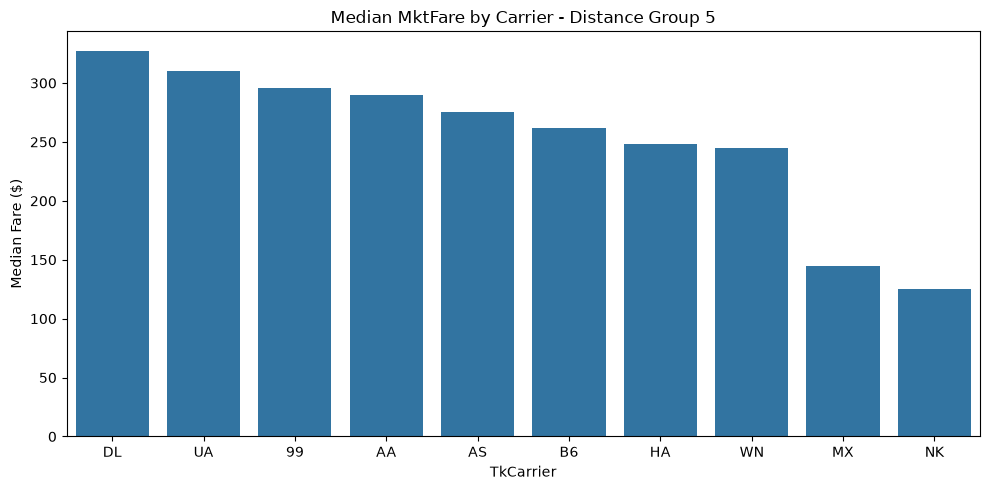

In [101]:
group = 5
plot_df = (df_eda[df_eda['MktDistanceGroup'] == group].groupby('TkCarrier')['MktFare'].agg(count = 'count', median = 'median').query("count >= 1000").reset_index().sort_values(by = 'median', ascending = False).head(10))

plt.figure(figsize=(10, 5))
sns.barplot(data = plot_df, x='TkCarrier', y='median')
plt.title(f'Median MktFare by Carrier - Distance Group {group}')
plt.ylabel('Median Fare ($)')
plt.tight_layout()
plt.show()





In [94]:
display(df_eda.groupby(['TkCarrier', 'MktDistanceGroup'])['MktFare'].agg(count = 'count', median = 'median').reset_index())

,TkCarrier,MktDistanceGroup,count,median
0,3M,1,2920,120.00
1,3M,2,114,123.00
2,99,1,7418,180.23
3,99,2,26059,217.95
4,99,3,29493,232.25
...,...,...,...,...
200,WN,16,1,461.00
201,XP,1,2559,53.50
202,XP,2,11191,74.00
203,XP,3,5630,88.50


Part 5: Volume vs Fare

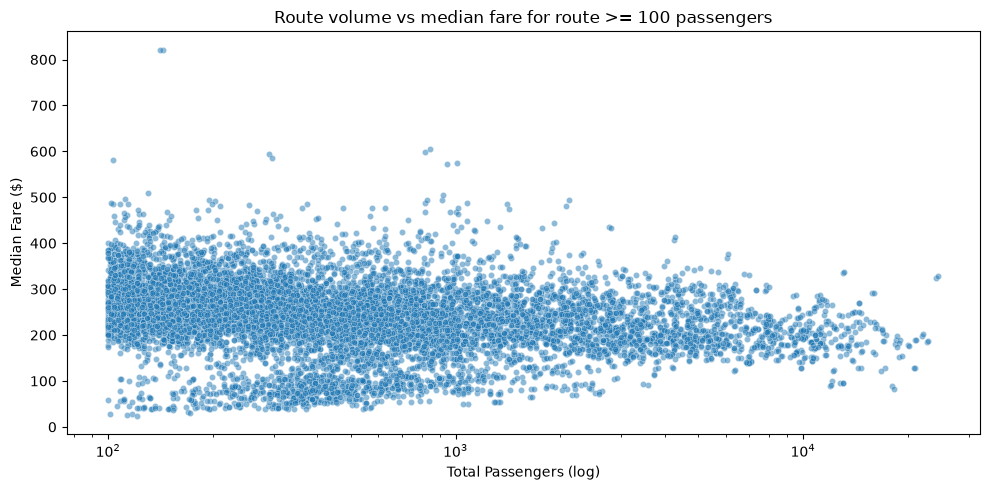

,total_passengers,median_fare
total_passengers,1.00,-0.31
median_fare,-0.31,1.00


In [102]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data = route_fare_analytics_filtered, x = 'total_passengers', y = 'median_fare', alpha = 0.5, s = 20)
plt.xscale('log')
plt.xlabel('Total Passengers (log)')
plt.ylabel('Median Fare ($)')
plt.title('Route volume vs median fare for route >= 100 passengers')
plt.tight_layout()
plt.show()

route_fare_analytics_filtered[['total_passengers', 'median_fare']].corr(method='spearman')




The analysis for this part was done using routes that has >= 100 total passengers(taken from part 3)

There is a slight downward trend observable as when total passengers increases, median fare decreases slightly. 
This observation is supported further by the spearman correlation. Since the realtionship of passenger volume vs fare is not strong, passenger volume alone is unable to account for the fare.

Part 6: Supporting Factors

,MktCoupons,count,median_fare
0,1,4166339,212.50
1,2,2869371,259.00
2,3,146703,313.00
3,4,6808,485.85
4,5,477,571.81
5,6,46,760.50
6,7,3,977.77


,MktGeoType,count,median_fare
0,1,520310,295.50
1,2,6669437,229.00


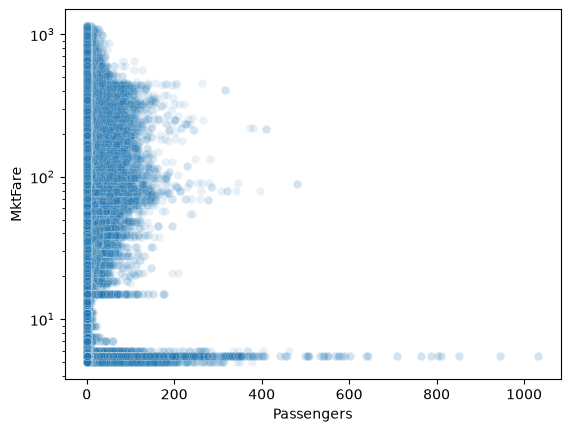

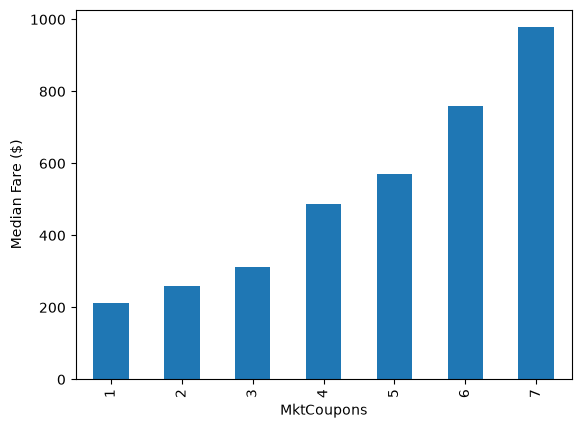

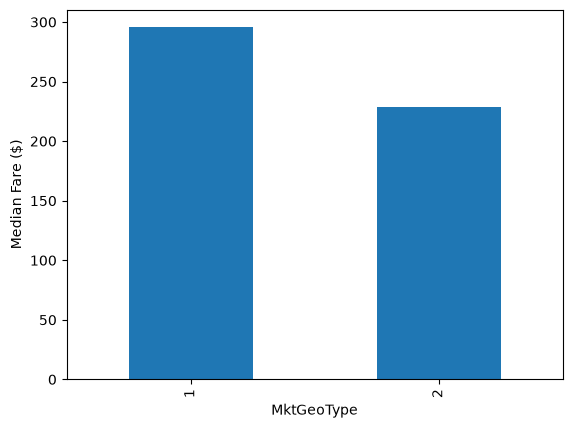

In [123]:
display(df_eda.groupby('MktCoupons')['MktFare'].agg(count = 'count', median_fare = 'median').reset_index())
display(df_eda.groupby('MktGeoType')['MktFare'].agg(count = 'count', median_fare = 'median').reset_index())

sns.scatterplot(data = df_eda, x = 'Passengers', y = 'MktFare', alpha = 0.1)
plt.yscale('log')
plt.show()

df_eda.groupby('MktCoupons')['MktFare'].median().plot(kind='bar')
plt.ylabel('Median Fare ($)')
plt.show()

df_eda.groupby('MktGeoType')['MktFare'].median().plot(kind='bar')
plt.ylabel('Median Fare ($)')
plt.show()



From the bar graph, we can see that as MktCoupons increases, MktFare does as well. So the number of stops in an itinerary has a relation with the Market Fare. 
We can also see that MktGeoType 1, which is non-mainland, has a higher market fare compared to MktGeoType 2.

The scatter graph of Passegners vs Fare is the same as that in notebook 1 with the exception of the log scale.

Part 7: Correlation Heatmaps

MktDistance         0.25
MktDistanceGroup    0.24
NonStopMiles        0.24
MktCoupons          0.13
MktGeoType         -0.11
Passengers         -0.11
extra_miles         0.08
Name: MktFare, dtype: float64


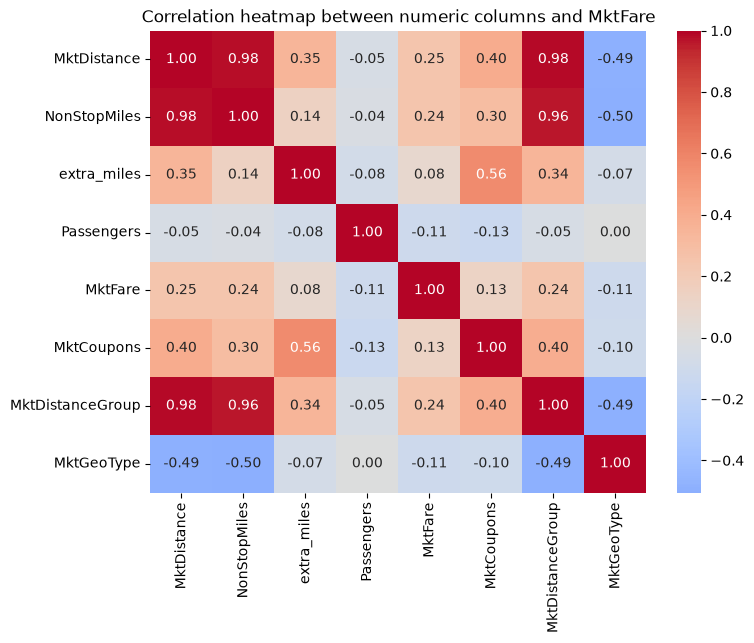

In [117]:
df_eda['extra_miles'] = df_eda['MktDistance'] - df_eda['NonStopMiles']

numeric_cols = ['MktDistance', 'NonStopMiles', 'extra_miles', 'Passengers', 'MktFare', 
'MktCoupons', 'MktDistanceGroup', 'MktGeoType']

corr_fare = df_eda[numeric_cols].corr()['MktFare'].drop('MktFare').sort_values(key=abs, ascending=False)
print(corr_fare)

plt.figure(figsize=(8, 6))
sns.heatmap(data = df_eda[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation heatmap between numeric columns and MktFare')
plt.show()


In general, there is a slight positive correlation between distance related columns and market fare, as these increases, market fare also increases. Higher MKtCoupon tends to also mean higher distance values, thus a higher market fare. Also all, the distance type columns have a similar correlation value with market fare, this means that it might be redundant to have all of them.

For MktGeoType, the values are only 1 and 2, thus the negative correlation shown states that MktGeoType 2(mainland) leads to lower market fare.

Passegners are also negativly correlated to market fare, representing a lower market fare for higher passenger count.

Part 8: Fare / Mile

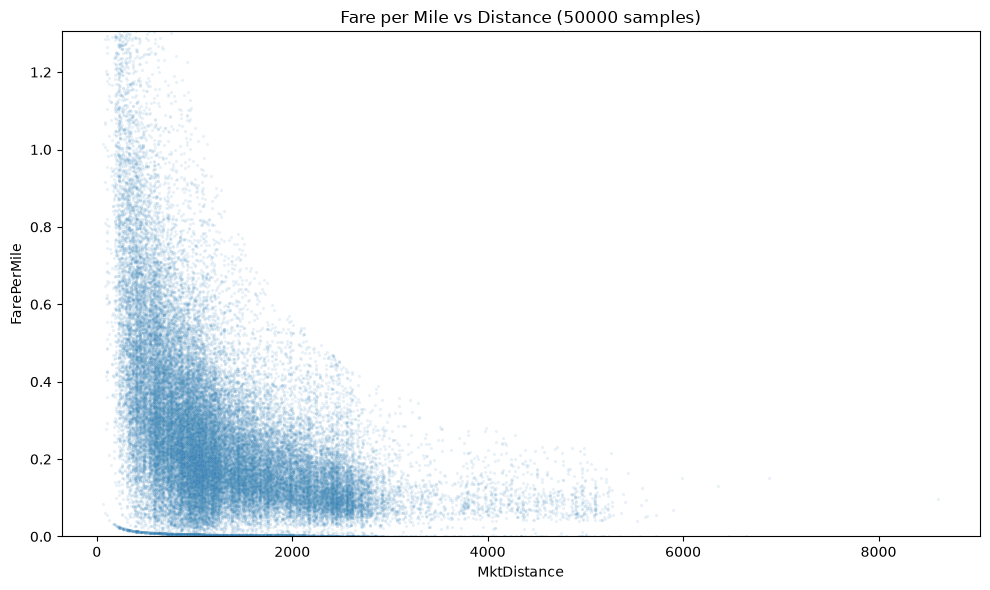

In [122]:
df_eda['FarePerMile'] = df_eda['MktFare']/df_eda['MktDistance']

sample_df = df_eda.sample(50000, random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(data = sample_df, x = 'MktDistance', y = 'FarePerMile', alpha=0.1, s=5)
plt.xlabel('MktDistance')
plt.ylabel('FarePerMile')
plt.title('Fare per Mile vs Distance (50000 samples)')
plt.ylim(0, sample_df["FarePerMile"].quantile(0.99))
plt.tight_layout()
plt.show()





From this scatterplot,  we can tell that Fare per Mile decreases as the distance increased, with much more variations in the short haul flights. However, market fare still increases with the distance generally(part 2), this shows that shorter routes have higher yield per mile.

Key EDA Findings

Which routes have the highest and lowest average fares?
The lowest average fare was on the route PGD-SAV with a fare of $27.06 while the highest average fare was on the route GUM-HNL with an average of $699.54. The latter fare is expected as it is from Guam to Hawaii.

Which route carries the most passengers?
LAX-JFK carries the most amount of passengers with a number of 24541. This is not a surprise as these two cities of Los Angeles and New York are synonymous with USA as a country. The second most would be the JFK-LAX carrying 24082 total passengers. 

How does fare vary by distance?
Using median Market Fare and distance groups, we can see that the fare rises as distance increases. This trend only stops from group 18 onwards due to lack of data

Which carriers have higher average fares?
AC has the highest average fare but it only has 1 record in the dataset. Thus, the carrier that has the highest average fare with at least 100 records is DL with $314.56

Are high volume routes cheaper or more expensive?
With the exception of LAX<—>JFK, higher volume routes are cheaper than lower volume routes. The top 15 routes hover around the median fare of $186 while the bottom 15 routes are at a median fare of $261